In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gmean, ttest_ind
from scipy.stats.mstats import winsorize

df = pd.read_csv(r'C:\Users\дмитрий\Desktop\лабы\bmw.csv') # Путь к вашему файлу

print(df.head())

# Т.к. в исходном датасете нет пропусков, создадим их для Заданий 2 и 3
# Добавим 10% пропусков в 'tax'
np.random.seed(42)
missing_idx = df.sample(frac=0.1).index
df.loc[missing_idx, 'tax'] = np.nan

       model  year  price transmission  mileage fuelType  tax   mpg  \
0   5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1   6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2   5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3   1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4   7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   

   engineSize  
0         2.0  
1         2.0  
2         3.0  
3         1.5  
4         3.0  


### Лаба 1.1

#### 1.1 Типы шкал

model - номинальная
<br>
year - интервальная (или шкала отношений)
<br>
transmission, fuelType - номинальные
<br>
price, mileage, tax, mpg, engineSize - шкала отношений

In [9]:
# индикатор пропуска
df['tax_missing'] = df['tax'].isna().astype(int)

# Проверка гипотезы MAR (Зависимость от года выпуска)
group_year = df.groupby('tax_missing')['year'].mean()
print(f"Средний год выпуска (0-есть данные, 1-пропуск):\n{group_year}")

# Проверка гипотезы MNAR (Зависимость от цены)
group_price = df.groupby('tax_missing')['price'].mean()
print(f"Средняя цена (0-есть данные, 1-пропуск):\n{group_price}")

# Реализация проверки (T-тест)
t_stat, p_val = ttest_ind(df[df['tax_missing']==0]['year'], df[df['tax_missing']==1]['year'])
print(f"P-value для гипотезы о равенстве лет: {p_val:.4f}")

Средний год выпуска (0-есть данные, 1-пропуск):
tax_missing
0    2017.069257
1    2017.166048
Name: year, dtype: float64
Средняя цена (0-есть данные, 1-пропуск):
tax_missing
0    22692.661136
1    23100.176252
Name: price, dtype: float64
P-value для гипотезы о равенстве лет: 0.1993


#### 1.2 Сравнение признаков: model (Номинальная) и price (Отношений)

In [10]:
stats_price = {
    "Среднее": df['price'].mean(),
    "Медиана": df['price'].median(),
    "Мода": df['price'].mode()[0]
}

stats_model = {
    "Среднее": "Ошибка (не применимо)",
    "Медиана": "Ошибка (не применимо)",
    "Мода": df['model'].mode()[0]
}

print(f"Статистики Price: {stats_price}")
print(f"Статистики Model: {stats_model}")

Статистики Price: {'Среднее': np.float64(22733.408867452), 'Медиана': np.float64(20462.0), 'Мода': np.int64(20980)}
Статистики Model: {'Среднее': 'Ошибка (не применимо)', 'Медиана': 'Ошибка (не применимо)', 'Мода': ' 3 Series'}


Для номинальной шкалы (model) единственная корректная мера центральной тенденции — мода. Попытка посчитать среднее значение для моделей машин (даже закодированных цифрами 1, 2, 3) приведет к получению информации, не имеющей физического смысла.

### 2. Диагностика типа пропусков

MCAR: Если $p > 0.05$, мы не можем отклонить гипотезу, что пропуски случайны.
<br>
MAR: Если $p < 0.05$ для года, значит пропуски связаны с возрастом машины.
<br>
MNAR: Если цена у «пропусков» аномально высокая, вероятно, данные скрыты намеренно.

### 3. Индикатор пропуска
<br>
1. Индикатор несет информацию, когда сам факт отсутствия данных является сигналом (например, налог не указан только для электрокаров).
<br>
2. Значимость индикатора в модели (например, в регрессии) говорит о том, что импутация (заполнение средним) "размыла" важный категориальный признак.

### 4. Выброс — ошибка или сигнал?

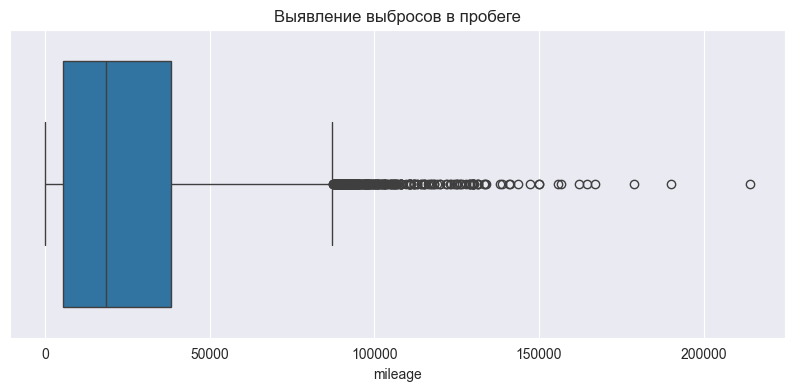

In [11]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['mileage'])
plt.title("Выявление выбросов в пробеге")
plt.show()

#### Анализ признака mileage:

1. Причины: Пробег в 200,000+ миль может быть реальным сигналом (машина из такси) или ошибкой ввода (лишний ноль).

2. Что хуже:

    Удалить: Опасно, мы теряем информацию о сильно изношенных авто.

    Оставить: Плохо для линейных моделей.

    Преобразование: Оптимально. Применение логарифма «подтянет» выброс к основному распределению.

### 5. Визуализация как инструмент мышления
<br>
Для цены (price) характерна сильная асимметрия.

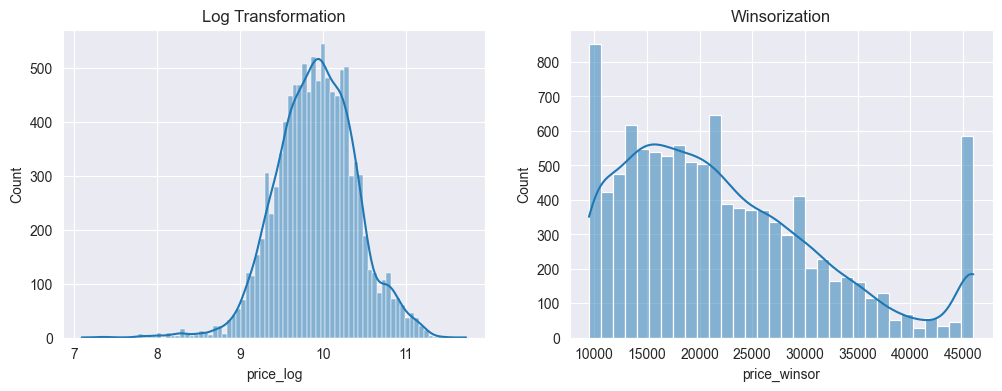

In [12]:
# 1. Логарифмирование
df['price_log'] = np.log1p(df['price'])

# 2. Винзоризация (замена экстремальных 5% значений)
df['price_winsor'] = winsorize(df['price'], limits=[0.05, 0.05])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price_log'], kde=True, ax=axes[0]).set_title("Log Transformation")
sns.histplot(df['price_winsor'], kde=True, ax=axes[1]).set_title("Winsorization")
plt.show()

Логарифмирование: Лучше для линейных моделей и визуализации распределения.

Винзоризация: Лучше для сохранения интерпретируемости (остаемся в тех же единицах — фунтах).

### 6. Средние, которые вводят в заблуждение

In [13]:
am = df['price'].mean()
md = df['price'].median()
gm = gmean(df['price'])

print(f"Арифметическое: {am:.2f}\nМедиана: {md:.2f}\nГеометрическое: {gm:.2f}")

Арифметическое: 22733.41
Медиана: 20462.00
Геометрическое: 20285.60


Объяснение: Арифметическое среднее завышено из-за «хвоста» дорогих моделей. Медиана лучше всего отражает «типичную» цену BMW на вторичном рынке, так как она устойчива к экстремальным значениям.

### 7. Неправильная диаграмма

Мы использовали sns.histplot для распределения цен.

Худшая диаграмма: Круговая диаграмма (Pie Chart) по всем уникальным значениям цен.

Она создаст сотни нечитаемых секторов.

### 8. Одна и та же информация - разные графики
<br>
Завершим работу построением матрицы корреляций для оценки взаимосвязей.

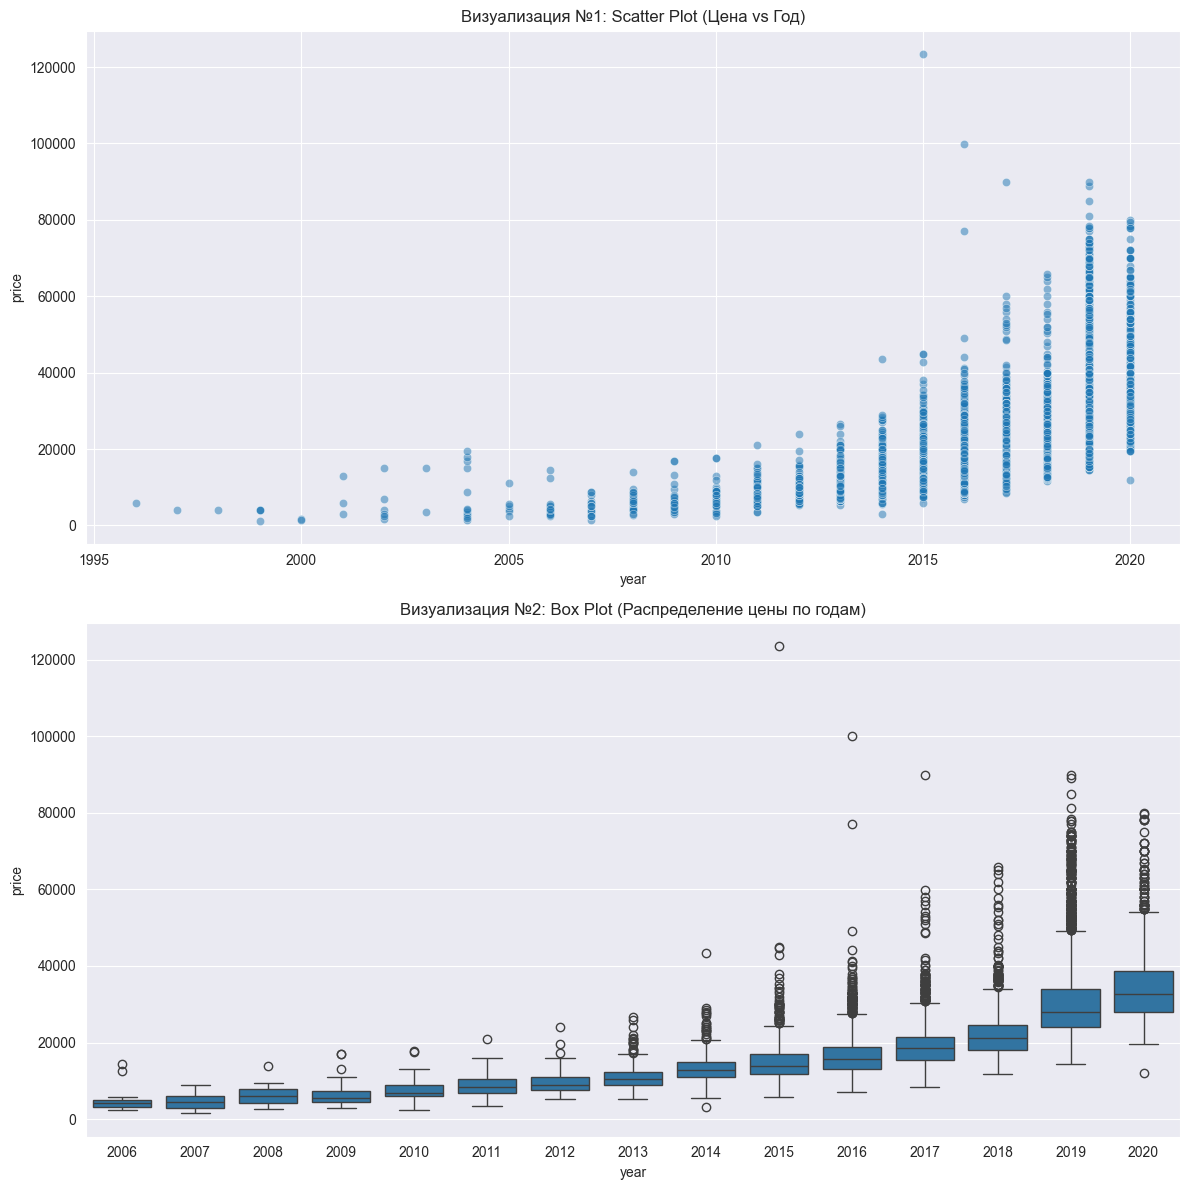

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# График №1: Scatter Plot
sns.scatterplot(data=df, x='year', y='price', alpha=0.5, ax=axes[0])
axes[0].set_title("Визуализация №1: Scatter Plot (Цена vs Год)")

# График №2: Box Plot
# Берем последние 15 лет для наглядности, чтобы график не был перегружен
top_years = df[df['year'] > 2005]
sns.boxplot(data=top_years, x='year', y='price', ax=axes[1])
axes[1].set_title("Визуализация №2: Box Plot (Распределение цены по годам)")

plt.tight_layout()
plt.show()

#### Что подчёркивает каждый график:
1. Scatter Plot: Подчёркивает общую форму зависимости и плотность данных. Мы сразу видим общую экспоненциальную кривую: чем свежее машина, тем круче растет цена вверх. Хорошо заметны единичные сверхдорогие модели (выбросы).

2. Box Plot: Подчёркивает статистические характеристики внутри каждого года. Он фокусирует внимание на медиане, межквартильном размахе (где сосредоточено 50% цен) и том, как увеличивается дисперсия (разброс цен) у новых автомобилей по сравнению со старыми.

#### Какие гипотезы легче заметить?
1. Есть ли в данных уникальные суперкары?

    Где лучше видно: На Точках.

    Почему: Одна точка, которая улетела высоко вверх над всеми остальными, сразу бросается в глаза. В "Ящиках" она может затеряться среди других выбросов.

2. Правда ли, что новые машины имеют более разную цену, чем старые?

    Где лучше видно: На Ящиках.

    Почему: Ты просто сравниваешь высоту "ящиков". Если ящик 2019 года намного длиннее ящика 2011 года, значит, у новых машин огромный разбор цен (из-за комплектаций), а старые все стоят примерно одинаково "дешево". На точках это понять сложнее, потому что они просто накладываются друг на друга.